In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D
import warnings; warnings.simplefilter('ignore')
import sys
import h5py
import pandas as pd
import seaborn as sns
sys.path.insert(0, '/Users/jsmonzon/Research/SatGen/mcmc/src/')
import jsm_ancillary
import jsm_visualize
import jsm_SHMR
import jsm_mcmc
import jsm_stats
import jsm_models
import evolve as ev
import galhalo as gh
import profiles as profiles
import config as cfg

In [3]:
plt.style.use('../../../SatGen/notebooks/paper1/paper.mplstyle')
double_textwidth = 7.0 #inches
single_textwidth = 3.5 #inches
levelz = [1-0.99, 1-0.95, 1-0.68]

In [4]:
S0 = jsm_ancillary.load_sample("../../data/MW/S0_fid.h5")
S15 = jsm_ancillary.load_sample("../../data/MW/S15_fid.h5")
S30 = jsm_ancillary.load_sample("../../data/MW/S30_fid.h5")

In [5]:
def clean_sample(ii, sub_key):

    Nsub_all = jsm_ancillary.make_matrix(ii, "N_"+sub_key)[:, 0]
    fsub_all = jsm_ancillary.make_matrix(ii, "f_"+sub_key)[:, 0]

    # Nsub_1st = jsm_ancillary.make_matrix(ii, "N_"+sub_key)[:, 1]
    # fsub_1st = jsm_ancillary.make_matrix(ii, "f_"+sub_key)[:, 1]

    # Nsub_2nd = jsm_ancillary.make_matrix(ii, "N_"+sub_key)[:, 3]
    # fsub_2nd = jsm_ancillary.make_matrix(ii, "f_"+sub_key)[:, 3]

    # Nsub_3rd = jsm_ancillary.make_matrix(ii, "N_"+sub_key)[:, 5]
    # fsub_3rd = jsm_ancillary.make_matrix(ii, "f_"+sub_key)[:, 5]

    df = pd.DataFrame({
        "logMvir": np.log10(ii.host_mass.values),
        "log1pz50": np.log10(1 + ii.host_z50.values),
        "logc": np.log10(ii.host_c),
        "logMs": np.log10(ii.MMs.values),
        "logNsub": np.log10(Nsub_all),
        "logfsub": np.log10(fsub_all)})

        # "logNsub_1st": np.log10(Nsub_1st),
        # "logfsub_1st": np.log10(fsub_1st),

        # "logNsub_2nd": np.log10(Nsub_2nd),
        # "logfsub_2nd": np.log10(fsub_2nd),

        # "logNsub_3rd": np.log10(Nsub_3rd),
        # "logfsub_3rd": np.log10(fsub_3rd),
    return df

In [6]:
S0_clean = clean_sample(S0, "artificial")[0:1000]
S15_clean = clean_sample(S15, "artificial")[0:1000]
S30_clean = clean_sample(S30, "artificial")[0:1000]

In [7]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

def bootstrap_correlation(df, key_x, key_y, N_sample, N_bootstrap=100):
    """
    Measure Spearman correlation between key_x and key_y for a random
    sample of size N_sample, with bootstrap errors from the remaining data.

    Parameters
    ----------
    df          : pandas DataFrame
    key_x       : column name for x variable (str)
    key_y       : column name for y variable (str)
    N_sample    : number of galaxies to sample (int)
    N_bootstrap : number of bootstrap iterations (int)

    Returns
    -------
    rho     : Spearman correlation on the selected sample (float)
    rho_err : bootstrap uncertainty (float)
    """
    sample  = df.sample(n=N_sample)
    rho, _  = stats.spearmanr(sample[key_x], sample[key_y])

    # with this
    rho_boot = np.zeros(N_bootstrap)
    for i in range(N_bootstrap):
        boot = df.sample(n=N_sample, replace=True)
        rho_boot[i], _ = stats.spearmanr(boot[key_x], boot[key_y])

    rho_err = np.std(rho_boot)
    return rho, rho_err


def correlation_vs_sample_size(df, key_x='logNsub', key_y='log1pz50',
                                N_base=45, N_bootstrap=100):
    """
    Measure how Spearman correlation between key_x and key_y scales
    with sample size N, starting from N_base and growing to the full sample.
    The final row is the correlation across the entire sample with no
    bootstrap error.

    Parameters
    ----------
    df          : pandas DataFrame
    key_x       : column name for x variable (str)
    key_y       : column name for y variable (str)
    N_base      : base sample size (int, default 45)
    N_bootstrap : number of bootstrap iterations per sample size (int)

    Returns
    -------
    results : DataFrame with columns [N, multiplier, rho, rho_err]
    """
    N_max        = len(df)
    multipliers  = np.arange(1, N_max // N_base + 1)
    sample_sizes = multipliers * N_base

    rows = []
    for N in sample_sizes:
        if N >= N_max:
            break
        rho, rho_err = bootstrap_correlation(df, key_x, key_y, N, N_bootstrap)
        rows.append({'N': N, 'multiplier': N // N_base, 'rho': rho, 'rho_err': rho_err})

    # final row: full sample, no error
    rho_full, _ = stats.spearmanr(df[key_x], df[key_y])
    rows.append({'N': N_max, 'multiplier': N_max / N_base, 'rho': rho_full, 'rho_err': np.nan})

    results = pd.DataFrame(rows)
    return results

In [8]:
S0_results_z50 = correlation_vs_sample_size(
    S0_clean,
    key_x='logNsub',
    key_y='log1pz50',
    N_base=45,
    N_bootstrap=50)

S0_results_c = correlation_vs_sample_size(
    S0_clean,
    key_x='logNsub',
    key_y='logc',
    N_base=45,
    N_bootstrap=50)

S0_results_Ms = correlation_vs_sample_size(
    S0_clean,
    key_x='logNsub',
    key_y='logMs',
    N_base=45,
    N_bootstrap=50)

In [9]:
S15_results_z50 = correlation_vs_sample_size(
    S15_clean,
    key_x='logNsub',
    key_y='log1pz50',
    N_base=45,
    N_bootstrap=50)

S15_results_c = correlation_vs_sample_size(
    S15_clean,
    key_x='logNsub',
    key_y='logc',
    N_base=45,
    N_bootstrap=50)

S15_results_Ms = correlation_vs_sample_size(
    S15_clean,
    key_x='logNsub',
    key_y='logMs',
    N_base=45,
    N_bootstrap=50)

In [10]:
S30_results_z50 = correlation_vs_sample_size(
    S30_clean,
    key_x='logNsub',
    key_y='log1pz50',
    N_base=45,
    N_bootstrap=50)

S30_results_c = correlation_vs_sample_size(
    S30_clean,
    key_x='logNsub',
    key_y='logc',
    N_base=45,
    N_bootstrap=50)

S30_results_Ms = correlation_vs_sample_size(
    S30_clean,
    key_x='logNsub',
    key_y='logMs',
    N_base=45,
    N_bootstrap=50)

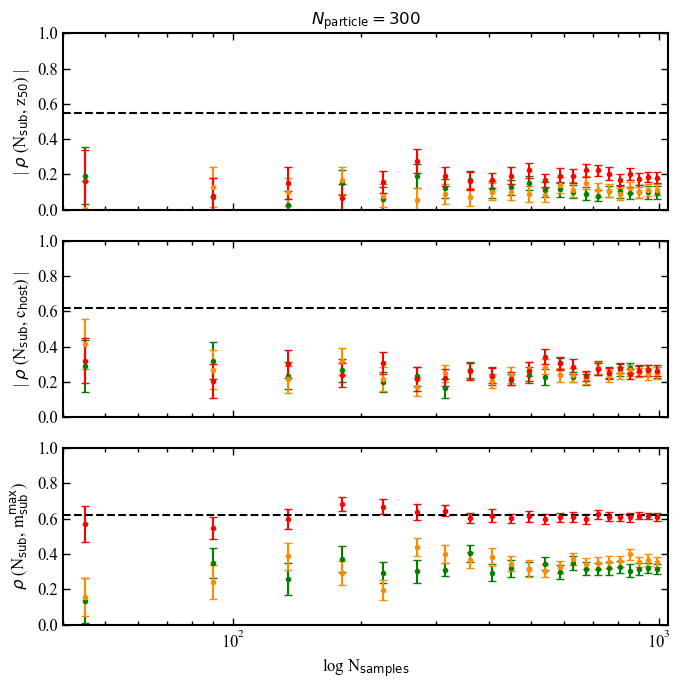

In [13]:
fig, ax = plt.subplots(3, 1, sharex=True, sharey=True, figsize=(double_textwidth, double_textwidth))

ax[0].errorbar(S0_results_z50['N'].iloc[:-1], np.abs(S0_results_z50['rho'].iloc[:-1]),
                yerr=S0_results_z50['rho_err'].iloc[:-1],
                marker='.', capsize=3, color='green', fmt='.',
                label='bootstrap samples')

ax[1].errorbar(S0_results_c['N'].iloc[:-1], np.abs(S0_results_c['rho'].iloc[:-1]),
                yerr=S0_results_c['rho_err'].iloc[:-1],
                marker='.', capsize=3, color='green', fmt='.',
                label='bootstrap samples')

ax[2].errorbar(S0_results_Ms['N'].iloc[:-1], S0_results_Ms['rho'].iloc[:-1],
                yerr=S0_results_Ms['rho_err'].iloc[:-1],
                marker='.', capsize=3, color='green', fmt='.',
                label='bootstrap samples',)

ax[0].errorbar(S15_results_z50['N'].iloc[:-1], np.abs(S15_results_z50['rho'].iloc[:-1]),
                yerr=S15_results_z50['rho_err'].iloc[:-1],
                marker='.', capsize=3, color='darkorange', fmt='.',
                label='bootstrap samples')

ax[1].errorbar(S15_results_c['N'].iloc[:-1], np.abs(S15_results_c['rho'].iloc[:-1]),
                yerr=S15_results_c['rho_err'].iloc[:-1],
                marker='.', capsize=3, color='darkorange', fmt='.',
                label='bootstrap samples')

ax[2].errorbar(S15_results_Ms['N'].iloc[:-1], S15_results_Ms['rho'].iloc[:-1],
                yerr=S15_results_Ms['rho_err'].iloc[:-1],
                marker='.', capsize=3, color='darkorange', fmt='.',
                label='bootstrap samples',)

ax[0].errorbar(S30_results_z50['N'].iloc[:-1], np.abs(S30_results_z50['rho'].iloc[:-1]),
                yerr=S30_results_z50['rho_err'].iloc[:-1],
                marker='.', capsize=3, color='red', fmt='.',
                label='bootstrap samples')

ax[1].errorbar(S30_results_c['N'].iloc[:-1], np.abs(S30_results_c['rho'].iloc[:-1]),
                yerr=S30_results_c['rho_err'].iloc[:-1],
                marker='.', capsize=3, color='red', fmt='.',
                label='bootstrap samples')

ax[2].errorbar(S30_results_Ms['N'].iloc[:-1], S30_results_Ms['rho'].iloc[:-1],
                yerr=S30_results_Ms['rho_err'].iloc[:-1],
                marker='.', capsize=3, color='red', fmt='.',
                label='bootstrap samples',)

ax[0].axhline(0.54856898, ls="--", color="k")
ax[1].axhline(0.61778284, ls="--", color="k")
ax[2].axhline(0.62226478, ls="--", color="k")

# array([-0.54856898, -0.61778284,  0.62226478])

ax[0].set_xscale("log")
ax[0].set_ylim(0, 1)
ax[0].set_xlim(40, 1050)

ax[0].set_ylabel("| $\\rho$ (N$_{\\rm sub}$, z$_{50}$) |")
ax[1].set_ylabel("| $\\rho$ (N$_{\\rm sub}$, c$_{\\rm host}$) |")
ax[2].set_ylabel("$\\rho$ (N$_{\\rm sub}$, m$_{\\rm sub}^{\\rm max}$)")
ax[2].set_xlabel("log N$_{\\rm samples}$")

ax[0].set_title("$N_{\\rm particle} = 300$")
plt.tight_layout()
plt.show()